# Tinder for RL 
## RLI 22.00 · Group Assignment · IE University BCSAI · 2026

### Part 01

---

## Introduction

The MountainCar problem presented in this RL assignment is interesting because:
It's simple enough to be solved, yet it's difficult enough to show the fundamental differences between learning algorithms. MountainCar involves an under-powered car in a valley attempting to reach a flag on the top of the right hand hill. The car is too weak to drive directly up, gravity pulls it down to the valley. 

The only possible way is to learn how to build up momentum through trial and error by oscillating to the left and right until there's enough potential energy to reach the goal, an unexpected solution.


Our study is organized around four scenarios that cross two axes: **action space type** (discrete vs. continuous) and **reward/cost formulation** (minimize steps vs. minimize fuel). Within each scenario we compare two algorithms suited to that action space. Across scenarios with the same action space, we hold the algorithms fixed and vary only the reward, isolating the effect of reward engineering on the learned policy.

For the **discrete scenarios**, we compare **Q-Learning** against **DQN**. Q-Learning discretizes the state space into bins and builds an explicit lookup table, giving us a fully interpretable policy, every state's preferred action can be read directly from the table and visualized as a phase portrait. DQN replaces that table with a neural network, operating on the raw continuous state without discretization loss. The comparison directly answers whether function approximation adds value on a problem this small, or whether the tabular method is already sufficient.

For the **continuous scenarios**, tabular methods are infeasible. We compare **TD3** and **SAC**, both actor-critic algorithms that learn a policy network alongside a value estimator. TD3 is deterministic: it outputs a single action per state and stabilizes training through twin critics and delayed updates. SAC is stochastic: it maximizes a entropy-augmented objective, explicitly rewarding the agent for maintaining an exploratory, spread-out policy. This entropy regularization is particularly relevant here: in scenarios where large actions are penalized, SAC's natural tendency toward low-magnitude, high-entropy behavior aligns directly with the cost structure of the problem.

The four scenarios together enable both algorithm benchmarking and a principled analysis of how reward shaping alters policy structure (which is, ultimately, what this assignment is about).






---



## Scenario 1 — Discrete MountainCar: Minimum Steps

**Environment**: `MountainCar-v0` · **Objective**: Reach the goal in as few timesteps as possible

---

The first scenario uses the discrete version of MountainCar with its default reward structure: the agent receives **−1 for every timestep** until it reaches the flag. The default environment provides no partial credit or progress signal (just a constant −1 penalty per timestep), so both algorithms add a +100 goal bonus during training to enable discovery, while evaluation uses the unmodified reward to measure true performance.

This makes the problem deceptively hard: 

the agent must stumble upon the goal through exploration before it can learn anything meaningful, and early in training almost every episode simply truncates at 200 steps.

The action space has three choices at each step: push left (0), do nothing (1), or push right (2). The optimal policy is not "always push right", the car would lack the torque to climb directly. It must learn to rock back and forth, building kinetic energy through momentum before committing to the final climb. This emergent behavior is what makes Scenario 1 a clean test of whether an algorithm can discover a multi-step, physically-grounded strategy from a sparse, undifferentiated reward signal.


### Algorithms

**Q-Learning** discretizes the continuous state space into a **40×40 grid** (position × velocity), yielding 1,600 discrete states. Each cell maps to a Q-value for each of the 3 actions, updated via the Bellman equation with a learning rate of **α = 0.1**, small enough for stable updates, large enough to learn within 25,000 episodes. The discount factor **γ = 0.99** keeps future rewards nearly as valuable as immediate ones, which matters here because the goal can only be reached many steps into the future. Exploration follows ε-greedy decay from **1.0 → 0.02** at a rate of **0.9997 per episode**, giving the agent a long exploratory phase before committing to a policy. Because the default −1/step signal is too sparse for tabular bootstrapping to work reliably, we add a **+100 goal bonus** on termination, this preserves the optimal policy ordering while giving the Q-table a concrete value to propagate backwards from. All randomness is seeded at **seed = 42**, applied to both `np.random` and the environment reset.

**DQN** uses the **same +100 goal bonus**, applied via a `ShapedMountainCar` gym wrapper that intercepts the reward on termination before it reaches the replay buffer. This is a deliberate design choice: by keeping the reward structure identical across both algorithms, any performance difference in Scenario 1 is attributable to the algorithm itself (tabular vs. function approximation)  rather than to asymmetric learning signals. The network is a **two-layer MLP [128, 128]** mapping the raw continuous state directly to Q-values. Learning rate is **5e-4**, with a **replay buffer of 50,000 transitions** and a **1,000-step warmup** before any gradient updates. Batches of **64 transitions** are sampled every **4 environment steps**, and the target network hard-updates every **1,000 steps**. Exploration decays from **1.0 → 0.02** over **35% of total timesteps**. Trained for **200,000 environment steps** at **seed = 42**.

Both algorithms are evaluated on the **unmodified −1/step reward**, the shaping is training-only. This separates the engineered learning signal from the true objective performance, making the evaluation metrics directly comparable across scenarios.

In [ ]:
import json
import pickle
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stable_baselines3 import DQN, SAC, TD3

## Step 1: Load and Compare Scenario 1 Results

In this first step, we load the saved evaluation metrics for **Scenario 1: Discrete MountainCar - Minimum Steps**.

The goal of this scenario is to compare two algorithms:

- **Q-learning with a Q-table**
- **Deep Q-Network (DQN)**

Both algorithms were trained on the same environment, `MountainCar-v0`, with the objective of reaching the goal in the fewest possible steps.


The evaluation results show that **Q-Learning performed better than DQN in Scenario 1**. Q-Learning reached a **100% success rate**, while DQN reached **81%**. Q-Learning also required fewer steps on average, with about **125 steps** compared to DQN’s **160 steps**.

The reward values follow the same pattern. Since MountainCar gives a negative reward for each step, a less negative reward is better. Therefore, Q-Learning’s average reward of **-125.31** is better than DQN’s **-160.05**.

Q-Learning also used less fuel on average, meaning it reached the goal with fewer non-neutral actions. However, DQN trained faster, taking about **33.63 seconds**, while Q-Learning took about **72.85 seconds**.

The steps comparison shows that **Q-Learning reached the goal more efficiently**, needing only **125.31 steps on average**, while **DQN required 160.05 steps on average**, meaning DQN took longer paths or failed to reach the goal more often.


Overall, these results suggest that for this simple discrete environment, **Q-Learning was more reliable and efficient**, while **DQN was faster to train but less consistent**.


**Finding**: Tabular methods remain superior for **small discrete** state spaces. The exact value storage and complete state exploration of **Q-learning outweighed DQN**'s generalization capabilities in this low-dimensional problem.


In [18]:
# Notebook is in root, results are in training/results/
METRICS_DIR = Path("training/results/scenario1/metrics")

# Check if path exists, if not try alternate location
if not METRICS_DIR.exists():
    METRICS_DIR = Path("results/scenario1/metrics")
    if not METRICS_DIR.exists():
        print("❌ Error: Results not found!")
        print("Make sure you've run the training scripts first:")
        print("  python training/scenario1_qlearning.py")
        print("  python training/scenario1_dqn.py")
        raise FileNotFoundError(f"No results found at {METRICS_DIR}")

with open(METRICS_DIR / "scenario1_qtable.json") as f:
    qtable_metrics = json.load(f)

with open(METRICS_DIR / "scenario1_dqn.json") as f:
    dqn_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)",     "success_rate_percent"),
    ("Avg Reward",           "average_reward"),
    ("Avg Steps",            "average_steps"),
    ("Avg Fuel",             "average_fuel"),
    ("Min Steps",            "min_steps"),
    ("Max Steps",            "max_steps"),
    ("Training Time (s)",    "training_time_seconds"),
]

print("=" * 57)
print("SCENARIO 1: Discrete MountainCar - Minimum Steps")
print("=" * 57)
print(f"{'Metric':<25} {'Q-Learning':>15} {'DQN':>15}")
print("-" * 57)
for label, key in metrics_to_show:
    q_val = qtable_metrics.get(key, "N/A")
    d_val = dqn_metrics.get(key, "N/A")
    if isinstance(q_val, float):
        print(f"{label:<25} {q_val:>15.2f} {d_val:>15.2f}")
    else:
        print(f"{label:<25} {str(q_val):>15} {str(d_val):>15}")
print("=" * 57)

SCENARIO 1: Discrete MountainCar - Minimum Steps
Metric                         Q-Learning             DQN
---------------------------------------------------------
Success Rate (%)                   100.00           81.00
Avg Reward                        -125.31         -160.05
Avg Steps                          125.31          160.05
Avg Fuel                           107.71          156.42
Min Steps                              95              97
Max Steps                             158             200
Training Time (s)                   72.85           33.63


## Step 2: Visualize Scenario 1 Training Curves

In this step, we load and display the saved training plots for **Scenario 1: Discrete MountainCar - Minimum Steps**.

The figure compares the learning behavior of:

- **Q-Learning**, shown on the left
- **DQN**, shown on the right

Each plot contains three training curves:

- **Reward**: shows how the agent’s performance improves during training
- **Steps**: shows whether the agent reaches the goal faster over time
- **Success Rate (%)**: shows how often the agent successfully reaches the goal

From the results, **Q-Learning shows a more stable learning pattern**. After around 7,000–8,000 episodes, its success rate becomes very high and stays close to 100% for most of the remaining training. The average number of steps also decreases, meaning the agent learns to reach the goal more efficiently.

The **DQN model also improves**, but its training is much noisier. Its reward increases and the number of steps decreases over time, but the success rate fluctuates more strongly. This suggests that DQN is learning the task, but its training is less stable than the Q-table approach in this simple discrete environment.

Overall, for Scenario 1, the training curves suggest that **Q-Learning performs more reliably**, while **DQN learns more gradually and with higher variance**.

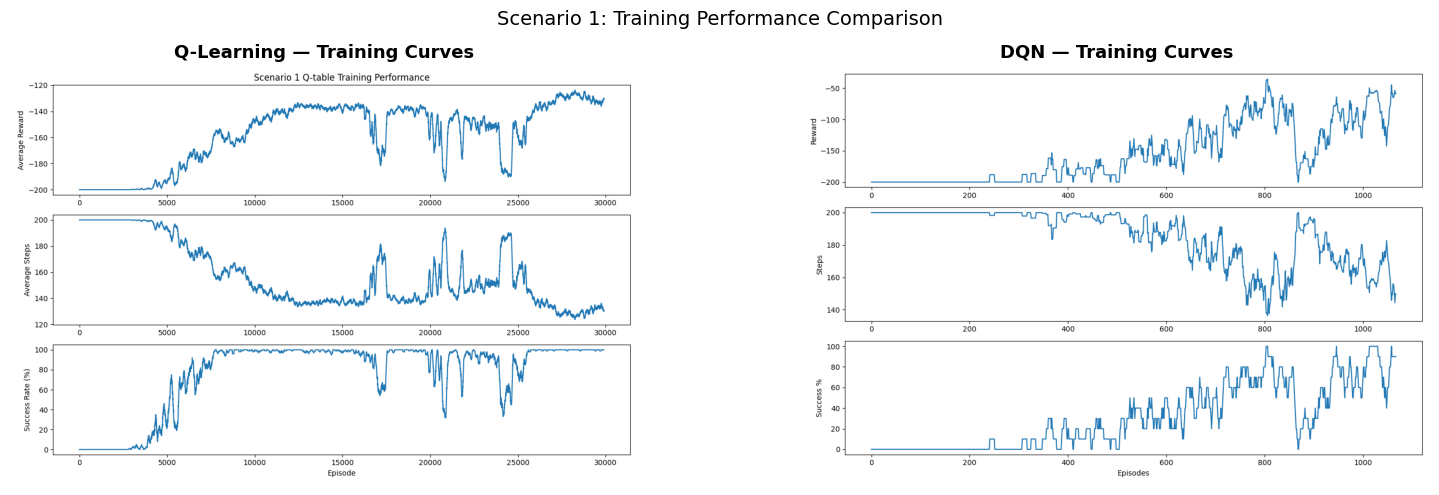

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Update to use correct path
SCENARIO1_DIR = Path("training/results/scenario1")

# Check if path exists, if not try alternate
if not SCENARIO1_DIR.exists():
    SCENARIO1_DIR = Path("results/scenario1")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qtable_img = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_qtable_training.png")
dqn_img    = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_dqn_training.png")

axes[0].imshow(qtable_img)
axes[0].axis("off")
axes[0].set_title("Q-Learning — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(dqn_img)
axes[1].axis("off")
axes[1].set_title("DQN — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 1: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Visualize the Learned Q-Learning Policy Map

In this step, we load the trained **Q-table model** for Scenario 1 and visualize the policy that the agent learned.

The Q-table stores the expected value of each action for every discretized state. Since `MountainCar-v0` has a continuous state space made of **position** and **velocity**, the state space was divided into bins during training. For each position-velocity pair, the code selects the action with the highest Q-value using:



RESULTS_DIR: training/results/scenario1
MODELS_DIR: training/results/scenario1/models
Q-table shape: (40, 40, 3)
Best action map shape: (40, 40)


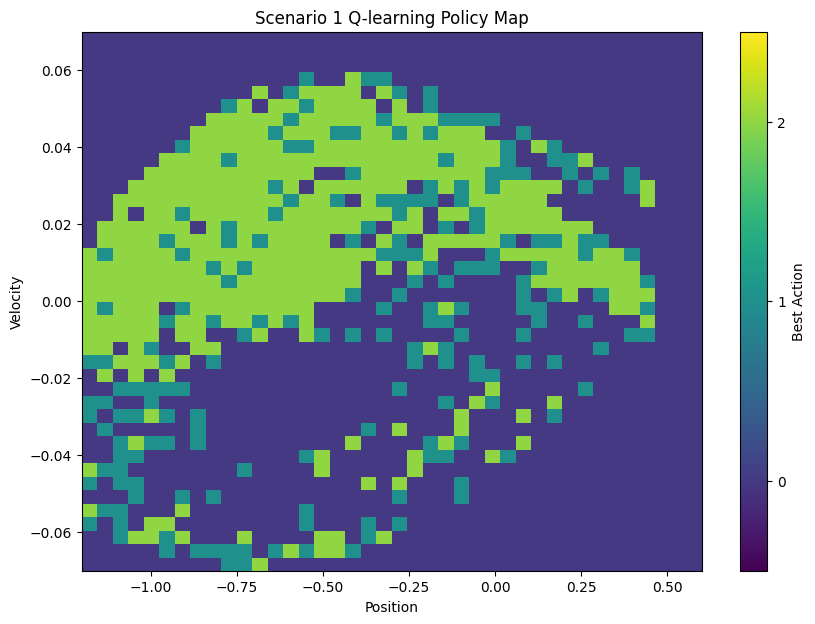

In [20]:

possible_roots = [
    Path("results/scenario1"),
    Path("training/results/scenario1"),
    Path("../results/scenario1"),
]

RESULTS_DIR = None

for path in possible_roots:
    if path.exists():
        RESULTS_DIR = path
        break

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find Scenario 1 results folder.")

MODELS_DIR = RESULTS_DIR / "models"
PLOTS_DIR = RESULTS_DIR / "plots"

print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)


# LOAD TRAINED Q-TABLE


with open(MODELS_DIR / "scenario1_qtable.pkl", "rb") as file:
    qtable_data = pickle.load(file)

q_table = qtable_data["q_table"]
position_bins = qtable_data["position_bins"]
velocity_bins = qtable_data["velocity_bins"]



# EXTRACT BEST ACTION FOR EACH STATE

best_actions = np.argmax(q_table, axis=2)

print("Q-table shape:", q_table.shape)
print("Best action map shape:", best_actions.shape)



# PLOT POLICY MAP


plt.figure(figsize=(10, 7))

plt.imshow(
    best_actions.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1],
    ],
)

plt.colorbar(ticks=[0, 1, 2], label="Best Action")
plt.clim(-0.5, 2.5)

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Policy Map")

plt.show()

### Conclusion

The Q-learning policy map shows that the agent learned a clear **momentum-based strategy** rather than simply pushing right all the time. In `MountainCar-v0`, the car cannot usually reach the goal by moving directly forward, so it must first move back and forth to build enough speed.

From the map, we can see that the best action changes depending on both **position** and **velocity**. When the car is moving in one direction, the policy often chooses actions that help increase that momentum. Then, once the car has enough speed or is in a better position

## Step 4: Why We Do Not Use a DQN Policy Map as a Main Result

For Q-learning, the policy map is directly meaningful because the model stores a **Q-table**. Each cell in the table corresponds to a discretized position-velocity state, and the best action can be read directly from that table.

For DQN, this is different. DQN does **not** store a table of actions for each state. Instead, it uses a neural network to approximate Q-values from continuous inputs. This means any DQN “policy map” must be artificially created by sampling a grid of position and velocity values and asking the model to predict an action for each point.

Because of this, the DQN policy map is only an approximation of the model’s behavior, not a direct representation of what the model stores internally. It can be useful for intuition, but it is not as clean or interpretable as the Q-learning policy map.

Therefore, in this analysis, we focus mainly on the numerical evaluation metrics and the training curves for DQN, while using the Q-learning policy map only as an interpretable visualization of the tabular method.

## Step 5: Visualize the Q-Learning Value Function

In this step, we visualize the **value function** learned by the Q-learning agent.

Instead of showing which action is selected in each state, this plot shows how valuable each position-velocity state is according to the trained Q-table. For each state, we take the maximum Q-value across all possible actions:



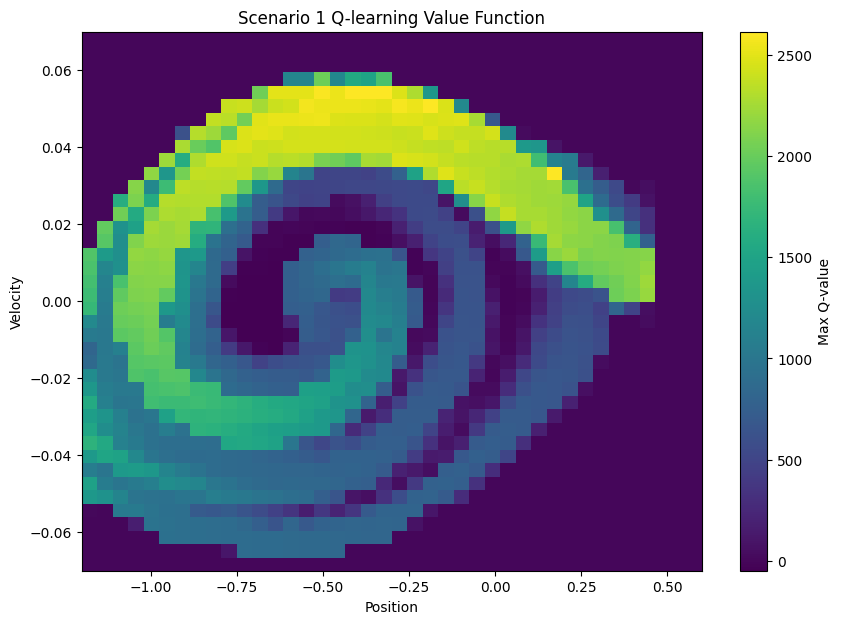

In [21]:
state_values = np.max(q_table, axis=2)

plt.figure(figsize=(10, 7))

plt.imshow(
    state_values.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(label="Max Q-value")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Value Function")

plt.show()

### Interpretation

The brighter areas show states with higher learned value, meaning the agent expects to reach the goal more easily from those position-velocity combinations. The darker areas represent lower-value states where the car is farther from success or does not have useful momentum.

The curved pattern appears because `MountainCar-v0` is a momentum-based task. The agent must move back and forth to build enough speed, so the value function depends on both **position** and **velocity**, not just how close the car is to the goal.

### Observations / Findings

The highest-value region appears near the right side of the state space, where the car is closer to the goal and has favorable velocity. Overall, the value function shows a meaningful structure, supporting that Q-learning learned an effective strategy for Scenario 1.

 Note on DQN Value Visualization

A similar value-function plot can be approximated for DQN by sampling position-velocity states and passing them through the trained neural network to obtain predicted Q-values. However, this is not as directly interpretable as the Q-learning value function, because DQN does not store explicit values for each discretized state.

Therefore, the Q-learning value map is used as a direct visualization of the tabular policy, while DQN is mainly compared through evaluation metrics and training curves.

## Step 6: Visualize Q-values for Individual Actions

In this step, we visualize the learned Q-values as 3D surfaces for specific actions.

The Q-table contains one value for each possible action in each discretized state. Since `MountainCar-v0` has three actions, the Q-table stores:

- `0`: move left
- `1`: no push
- `2`: move right

Here, we plot the Q-value surfaces for **move right** and **move left**. The x-axis represents position, the y-axis represents velocity, and the z-axis represents the learned Q-value for that action.


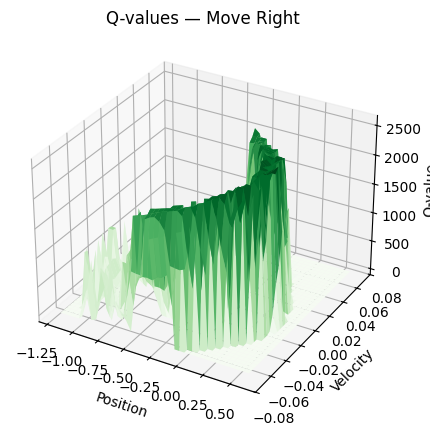

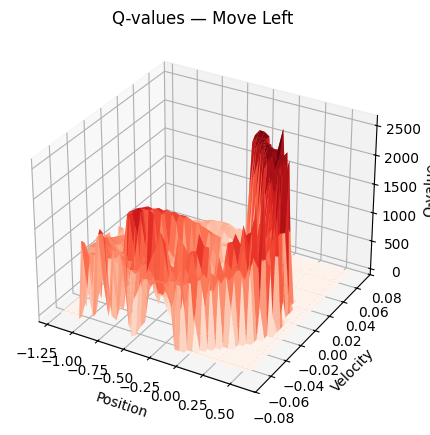

In [22]:
from mpl_toolkits.mplot3d import Axes3D

def plot_surface(Z, title, cmap):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap=cmap)

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_zlabel("Q-value")
    ax.set_title(title)

    plt.show()


# Create grid (use bins you already loaded)
X, Y = np.meshgrid(position_bins, velocity_bins)

Z_left  = q_table[:, :, 0]
Z_none  = q_table[:, :, 1]
Z_right = q_table[:, :, 2]

plot_surface(Z_right, "Q-values — Move Right", "Greens")
plot_surface(Z_left,  "Q-values — Move Left",  "Reds")

### Interpretation

The 3D surfaces show how valuable each action is in different parts of the state space. Higher peaks mean the agent expects that action to lead to better future rewards from that position and velocity.

The **move right** surface has high values in regions where the car is closer to the right hill and has useful momentum toward the goal. This shows that the agent learned when pushing right is beneficial.

The **move left** surface also has high values in certain regions, especially where moving left helps the car build backward momentum. This is important because MountainCar requires the agent to swing back before it can climb the hill.

### Observations / Findings

These plots show that Q-learning did not learn a single fixed action. Instead, it learned that the usefulness of each action depends on the current combination of **position** and **velocity**.

This supports the idea that the Q-table learned the physics of the environment: sometimes pushing left is useful for building momentum, and sometimes pushing right is useful for reaching the goal.

### Note on DQN Q-value Surfaces

A similar 3D Q-value surface could be approximated for DQN by sampling position-velocity states and passing them through the trained neural network. However, unlike Q-learning, DQN does not store explicit Q-values for each state-action pair.

For this reason, the Q-learning Q-value surfaces are more meaningful as direct visualizations of the learned table. For DQN, evaluation metrics and training curves are more reliable comparison tools because they show the model’s actual performance without relying on an artificial sampled grid.

## Step 7: Plot the Q-Learning Phase Portrait

In this step, we visualize the actual trajectories followed by the trained Q-learning agent.

A **phase portrait** plots the car’s **position** against its **velocity** over time. Instead of only looking at final evaluation metrics, this helps us understand the physical movement pattern learned by the agent.

For `MountainCar-v0`, a successful policy should not simply push right from the start. The car needs to move back and forth through the valley to build enough momentum before climbing the right hill.

Each line in the plot represents one evaluation episode with a different random seed. The legend shows how many steps the agent needed in each run.


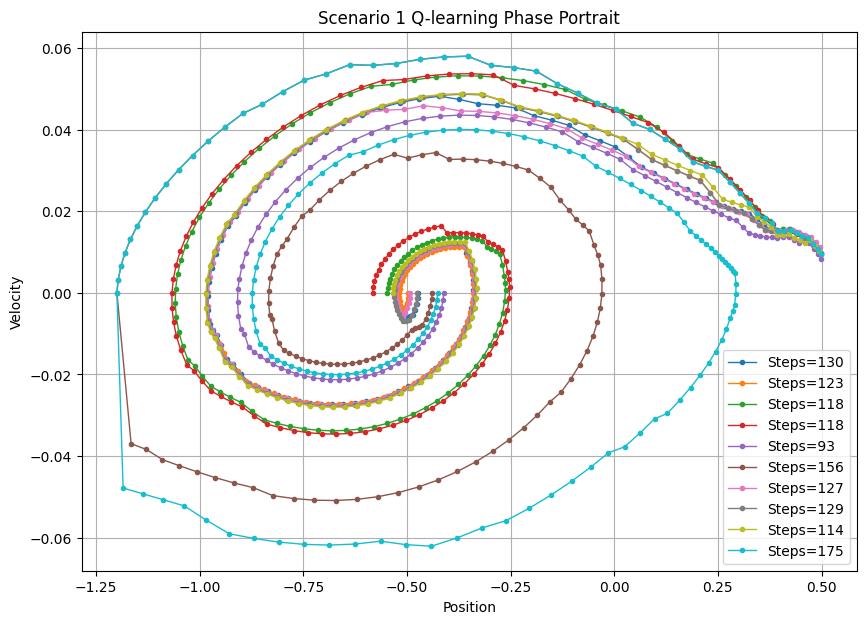

In [23]:
def discretize_state(state, position_bins, velocity_bins):
    position = state[0]
    velocity = state[1]

    position_index = np.digitize(position, position_bins) - 1
    velocity_index = np.digitize(velocity, velocity_bins) - 1

    position_index = np.clip(position_index, 0, len(position_bins) - 1)
    velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

    return position_index, velocity_index


def run_qtable_episode(q_table, position_bins, velocity_bins, seed=None):
    env = gym.make("MountainCar-v0")

    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []
    actions = []
    total_reward = 0

    for step in range(200):
        discrete_state = discretize_state(state, position_bins, velocity_bins)
        action = int(np.argmax(q_table[discrete_state]))

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "reward": total_reward,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }


plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_qtable_episode(q_table, position_bins, velocity_bins, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The trajectories form curved loops through the position-velocity space. This is expected for MountainCar because the car must swing backward and forward to gain speed.

Most trajectories first move left or downward in the phase space, then loop around and move toward the right side of the plot. This shows that the agent learned to use momentum instead of trying to go directly to the goal.

The different step counts show that some starting states are easier than others. Episodes with fewer steps reached the goal faster, while longer trajectories needed more back-and-forth movement before succeeding.

### Observations / Findings

The phase portrait confirms that the Q-learning policy learned the correct physical strategy for MountainCar. The agent uses velocity and position together, builds momentum through repeated swings, and eventually climbs toward the goal.

This supports the earlier policy map and value function results: Q-learning did not just memorize random actions, but learned a meaningful momentum-based behavior.

## Step 8: Plot the DQN Phase Portrait

In this step, we plot the phase portrait for the trained **DQN agent** in Scenario 1.

A phase portrait shows the car’s **position** against its **velocity** during an episode. This helps us understand the actual movement pattern learned by the model, not just the final numerical results.

For DQN, the action is selected using the trained neural network:


training/results/scenario1/models
[PosixPath('training/results/scenario1/models/scenario1_dqn.zip')]


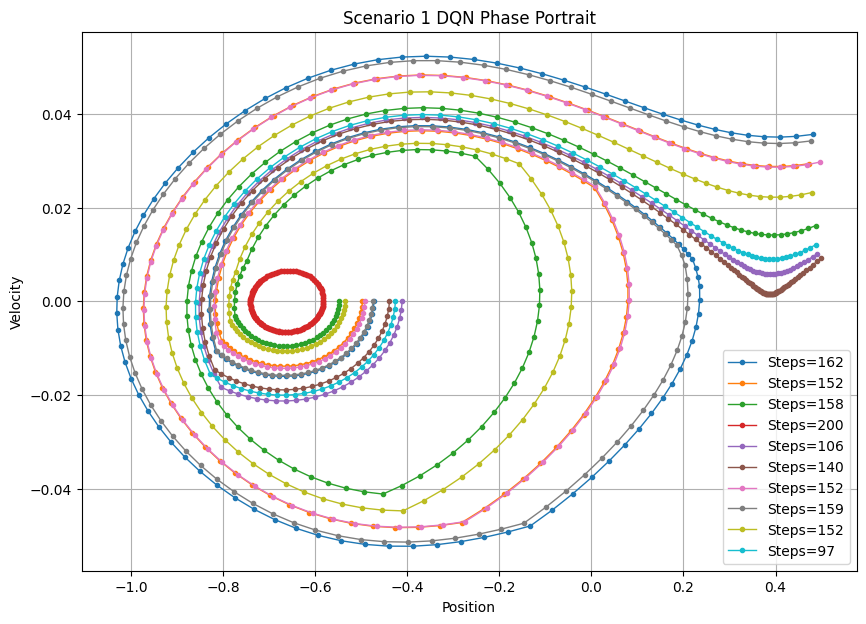

In [26]:
from pathlib import Path

BASE_DIR = Path("training/results")

METRICS_DIR = BASE_DIR / "scenario1" / "metrics"
MODELS_DIR  = BASE_DIR / "scenario1" / "models"
PLOTS_DIR   = BASE_DIR / "scenario1" / "plots"

print(MODELS_DIR)
print(list(MODELS_DIR.glob("scenario1_dqn*")))

dqn_model = DQN.load(MODELS_DIR / "scenario1_dqn")


def run_dqn_episode(model, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []
    actions = []
    total_reward = 0

    for step in range(200):
        action, _ = model.predict(state, deterministic=True)
        action = int(action)

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "reward": total_reward,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }


plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_dqn_episode(dqn_model, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 DQN Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The DQN trajectories show that the agent learned the general `MountainCar-v0` strategy: it moves back and forth through the valley to build momentum before trying to climb the right hill.

However, the DQN results are less consistent than Q-learning. Some episodes finish quickly, such as the run with **97 steps**, while others take much longer, including one episode that reaches the maximum limit of **200 steps**. This matches the metric table, where DQN had a lower success rate and a higher average number of steps.

### Comparison with Q-learning

Compared to the Q-learning phase portrait, the DQN phase portrait shows more variability between episodes. Q-learning produces more consistently successful trajectories, while DQN sometimes follows longer loops before reaching the goal or fails to finish within the time limit.

Overall, this supports the conclusion that **Q-learning is more reliable in Scenario 1**. Since the environment is simple and discrete, the Q-table can learn more precise state-action decisions. DQN still learns the correct momentum-based behavior, but its neural network approximation makes the policy less stable across different starting states.

## Step 9: Q-Learning State Visitation Map

In this step, we count how often the trained Q-learning agent visits each position-velocity region over 100 episodes.

The heatmap shows the parts of the state space that the agent uses most often while following its learned policy. Brighter areas mean that those states were visited more frequently.

### Interpretation

The visited states form a spiral-like path, which matches the expected MountainCar behavior. The agent repeatedly moves through the valley to build momentum before climbing toward the goal.

The brightest areas show the most common parts of the trajectory, especially around the central valley and near the final climb. This confirms that the Q-learning agent follows a consistent momentum-building strategy instead of moving randomly through the state space.

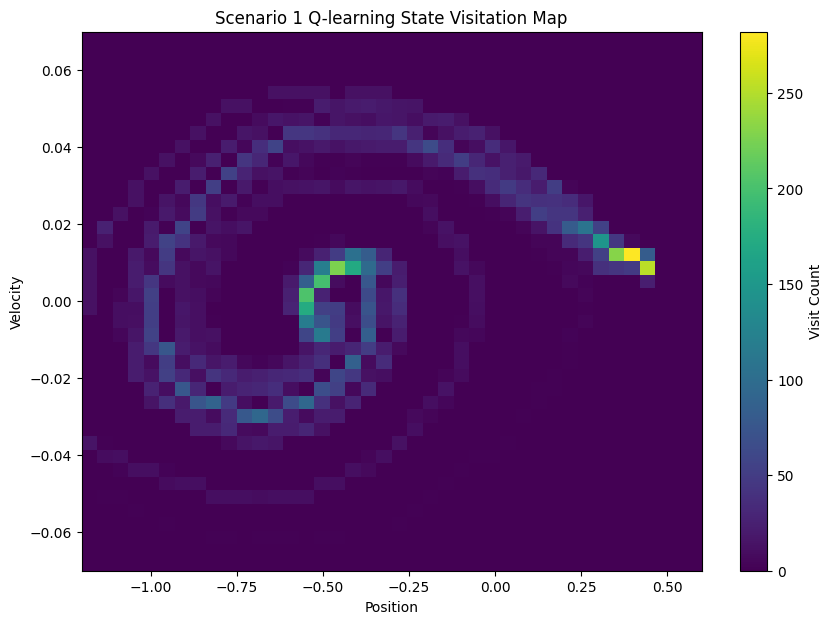

In [25]:
visit_counts = np.zeros((len(position_bins), len(velocity_bins)))

for seed in range(100):
    episode = run_qtable_episode(q_table, position_bins, velocity_bins, seed=seed)

    for position, velocity in zip(episode["positions"], episode["velocities"]):
        position_index = np.digitize(position, position_bins) - 1
        velocity_index = np.digitize(velocity, velocity_bins) - 1

        position_index = np.clip(position_index, 0, len(position_bins) - 1)
        velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

        visit_counts[position_index, velocity_index] += 1

plt.figure(figsize=(10, 7))

plt.imshow(
    visit_counts.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(label="Visit Count")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning State Visitation Map")

plt.show()

Note on DQN Visualizations

DQN is less directly visualizable because it does not store one value per state-action pair. Instead, it uses a neural network to approximate Q-values from continuous inputs. Any DQN policy map or value map would have to be created by manually sampling a grid of states and asking the model for predictions, so it is only an approximation of the model’s behavior.

Because of this, the DQN analysis is less interpretable than the Q-learning analysis. However, we still included the most meaningful visual comparisons possible, especially the training curves and phase portrait, which show how the DQN agent actually behaves during evaluation.

### Scenario 1 Interpretation and Conclusion

In Scenario 1, **Q-learning performed better than DQN** because `MountainCar-v0` is a simple, low-dimensional environment that can be discretized effectively. The Q-table directly stores values for each position-velocity bin and action, which makes the policy stable and easy to interpret.

The policy map, value function, visitation map, and phase portrait all show that Q-learning learned the correct MountainCar strategy: the car does not simply push right, but moves back and forth to build momentum before climbing the right hill.

DQN also learned part of this behavior, but its results were less consistent. Since DQN uses a neural network to approximate Q-values, it is less interpretable and can be noisier in small environments where a Q-table is already enough.

Overall, this scenario shows that **deep RL is not always the best choice**. For small discrete or easily discretized problems, tabular Q-learning can be simpler, more reliable, and more interpretable.

## Scenario 2 — Continuous MountainCar: Minimum Fuel

**Environment**: `MountainCarContinuous-v0` · **Objective**: Reach the goal while minimizing fuel usage

---

In the second scenario, we move to the continuous version of the environment. Unlike the discrete version where actions are fixed steps, the continuous car can apply a variable amount of force between **-1.0 and +1.0**. The objective is shifted from speed to **efficiency**: the agent is penalized by the **square of the action** at every timestep.

This creates a different challenge: the agent must still build momentum, but it must do so using as little force as possible. "Flooring it" is no longer the optimal strategy. This scenario tests whether continuous control algorithms can balance the physics of the mountain with a cost-sensitive objective.

### Algorithms

**SAC (Soft Actor-Critic)** is an off-policy actor-critic algorithm that uses **entropy regularization**. It maximizes a trade-off between expected reward and entropy, encouraging exploration and robust policies. For the fuel-minimization task, SAC's stochastic nature and entropy bonus are theoretically useful for discovering efficient paths, as it naturally tries to avoid high-magnitude actions unless they are necessary for the long-term goal.

**TD3 (Twin Delayed DDPG)** is a deterministic actor-critic algorithm. It improves upon DDPG by using twin critics to reduce overestimation bias and delayed policy updates to improve stability. TD3 is often more sample-efficient than SAC in stable environments, but its deterministic policy might lead to less exploration in the sparse-reward valley of MountainCar.

Both algorithms were trained for **300,000 timesteps** using enhanced reward shaping that rewards progress (change in position) and velocity, while penalizing fuel usage. Evaluation is performed on the standard environment to measure true fuel efficiency.

## Step 1: Load and Compare Scenario 2 Results

In this first step, we load the saved evaluation metrics for **Scenario 2: Continuous MountainCar - Minimum Fuel**.

The goal of this scenario is to compare two continuous-control algorithms:

- **Soft Actor-Critic (SAC)**
- **Twin Delayed DDPG (TD3)**

Both agents were trained on `MountainCarContinuous-v0`, where the car must still build momentum to reach the goal, but now every action also has a fuel penalty. This changes the question from *can the agent reach the flag?* to *can the agent reach the flag efficiently?*

The evaluation results show that **TD3 clearly outperformed SAC in Scenario 2**. TD3 reached a **100% success rate**, while SAC reached **0%**. TD3 also needed far fewer steps on average, about **65.8 steps** compared with SAC's **999**, which means SAC timed out in every evaluation episode.

The reward values reinforce the same conclusion. TD3 achieved a strongly positive average reward of **93.55**, while SAC stayed near **-5.02**. Since the continuous environment rewards success but subtracts a fuel penalty, this means TD3 found trajectories that actually solved the task, whereas SAC improved its shaped training behavior without learning a policy that consistently escaped the valley.

The raw fuel numbers need a small caution in interpretation. **SAC appears to use less fuel on average**, but that is mainly because it never reaches the goal and often applies weaker actions for 999 ineffective steps. **TD3 uses slightly more force overall, but converts that force into successful, short trajectories**, which is the behavior that actually matches the scenario objective.

TD3 was also faster to train, taking about **748.93 seconds**, while SAC needed about **1363.06 seconds**.

Overall, these results suggest that for this continuous, fuel-aware version of MountainCar, **TD3 was both more reliable and more practical**. It discovered a stable momentum-building strategy within the training budget, while SAC remained stuck in a non-solving regime.

**Finding**: In this **continuous control** setting, the deterministic policy learned by **TD3** was better aligned with the task than SAC's stochastic policy. TD3 found a repeatable momentum-building solution; SAC did not convert exploration into goal-reaching behavior.

In [2]:
import json
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stable_baselines3 import SAC, TD3

SCENARIO2_DIR = Path("training/results/scenario2")

if not SCENARIO2_DIR.exists():
    SCENARIO2_DIR = Path("results/scenario2")
    if not SCENARIO2_DIR.exists():
        print("Error: Scenario 2 results not found.")
        print("Run the training scripts first:")
        print("  python training/scenario2_sac.py")
        print("  python training/scenario2_td3.py")
        raise FileNotFoundError(f"No results found at {SCENARIO2_DIR}")

METRICS_DIR_2 = SCENARIO2_DIR / "metrics"

with open(METRICS_DIR_2 / "scenario2_sac.json") as f:
    sac_metrics = json.load(f)

with open(METRICS_DIR_2 / "scenario2_td3.json") as f:
    td3_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)", "success_rate_percent"),
    ("Avg Reward", "average_reward"),
    ("Avg Steps", "average_steps"),
    ("Avg Fuel", "average_fuel"),
    ("Min Steps", "min_steps"),
    ("Max Steps", "max_steps"),
    ("Training Time (s)", "training_time_seconds"),
]

comparison_rows = []
for label, key in metrics_to_show:
    comparison_rows.append(
        {
            "Metric": label,
            "SAC": sac_metrics.get(key, "N/A"),
            "TD3": td3_metrics.get(key, "N/A"),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("Metric")

print("=" * 62)
print("SCENARIO 2: Continuous MountainCar - Minimum Fuel")
print("=" * 62)
print(f"{'Metric':<25} {'SAC':>15} {'TD3':>15}")
print("-" * 62)
for label, key in metrics_to_show:
    sac_value = sac_metrics.get(key, "N/A")
    td3_value = td3_metrics.get(key, "N/A")
    if isinstance(sac_value, float):
        print(f"{label:<25} {sac_value:>15.2f} {td3_value:>15.2f}")
    else:
        print(f"{label:<25} {str(sac_value):>15} {str(td3_value):>15}")
print("=" * 62)

if td3_metrics["average_steps"] > 0:
    speedup = sac_metrics["average_steps"] / td3_metrics["average_steps"]
    print(f"TD3 reaches the goal about {speedup:.1f}x faster than SAC's timeout baseline.")
print("Note: SAC's lower raw fuel cost is misleading because it never solves the task.")
print("A fuel-efficient policy must still reach the flag consistently.")

comparison_df.round(2)

SCENARIO 2: Continuous MountainCar - Minimum Fuel
Metric                                SAC             TD3
--------------------------------------------------------------
Success Rate (%)                     0.00          100.00
Avg Reward                          -5.02           93.55
Avg Steps                          999.00           65.80
Avg Fuel                            50.17           64.51
Min Steps                             999              65
Max Steps                             999              67
Training Time (s)                 1363.06          748.93
TD3 reaches the goal about 15.2x faster than SAC's timeout baseline.
Note: SAC's lower raw fuel cost is misleading because it never solves the task.
A fuel-efficient policy must still reach the flag consistently.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


,SAC,TD3
Metric,,
Success Rate (%),0.00,100.00
Avg Reward,-5.02,93.55
Avg Steps,999.00,65.80
Avg Fuel,50.17,64.51
Min Steps,999.00,65.00
Max Steps,999.00,67.00
Training Time (s),1363.06,748.93


## Step 2: Visualize Scenario 2 Training Curves

In this step, we load and display the saved training plots for **Scenario 2: Continuous MountainCar - Minimum Fuel**.

The figure compares the learning behavior of:

- **SAC**, shown on the left
- **TD3**, shown on the right

Each plot contains two training curves:

- **Reward**: shows whether the policy is improving under the shaped training objective
- **Steps**: shows whether the agent is learning to finish episodes more quickly

The training curves reveal an important difference between **appearing to improve** and **actually learning to solve the task**.

For **SAC**, the average training reward rises from strongly negative values to mildly positive values, which means the agent is learning something under the shaped reward. However, the average episode length stays flat at **999 steps** throughout training. That means SAC never leaves the timeout regime. In other words, the reward shaping helps SAC improve local behavior, but not enough to produce a successful end-to-end solution.

For **TD3**, the curves show a much cleaner learning transition. Reward rises sharply early in training and then stabilizes at a high level, while the average number of steps collapses from nearly **1000** to roughly **70** and stays there. This is exactly what we would want in a minimum-fuel scenario: the policy becomes both successful and stable.

Overall, the training curves suggest that **TD3 learns faster and converges more reliably**, while **SAC plateaus in a partially improved but still unsuccessful regime**.

**Finding**: TD3 does not just finish with better metrics; it shows a much stronger training signal of real convergence. SAC's reward curve alone would look promising, but the flat step curve reveals that it never actually solves the environment.

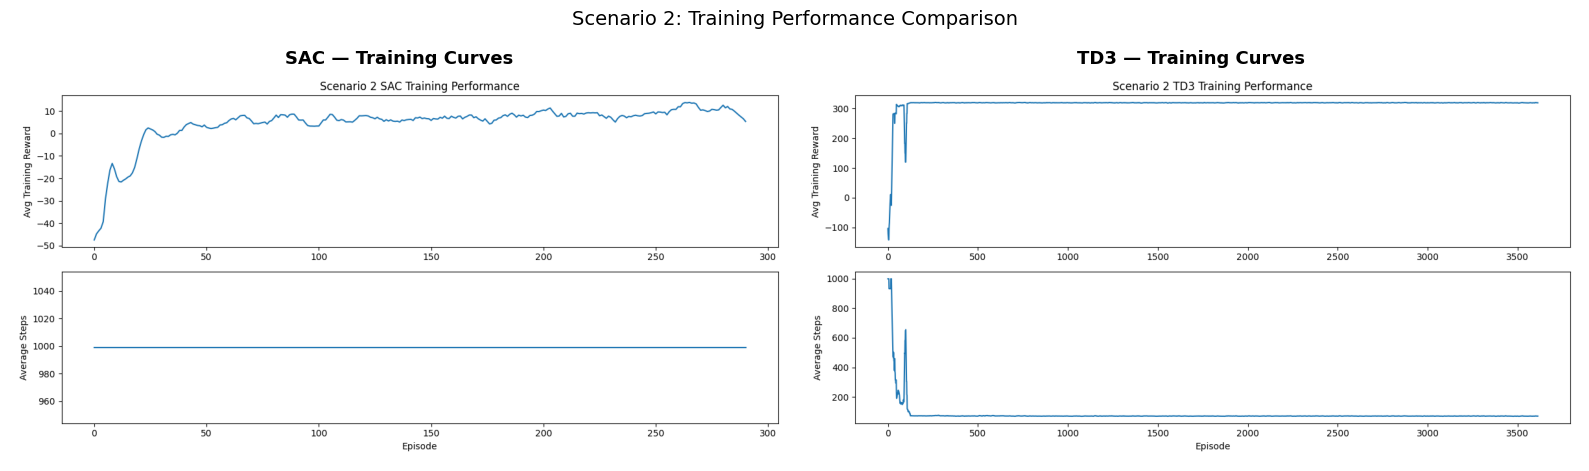

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sac_plot_path = SCENARIO2_DIR / "plots" / "scenario2_sac_training.png"
td3_plot_path = SCENARIO2_DIR / "plots" / "scenario2_td3_training.png"

if not sac_plot_path.exists() or not td3_plot_path.exists():
    raise FileNotFoundError("Scenario 2 training plots were not found in the saved results folder.")

img_sac = plt.imread(sac_plot_path)
img_td3 = plt.imread(td3_plot_path)

axes[0].imshow(img_sac)
axes[0].axis("off")
axes[0].set_title("SAC — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(img_td3)
axes[1].axis("off")
axes[1].set_title("TD3 — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 2: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Plot Phase Portraits and Action Profiles

In this step, we visualize the behavior of the trained continuous-control agents by running evaluation episodes and plotting their trajectories in the **position-velocity phase space**.

For Scenario 2, these behavior plots are especially important because the numerical metrics alone do not show *how* the agent is using force. A successful policy should:

- build momentum by oscillating through the valley
- time the final climb correctly
- avoid wasting fuel through unnecessary large actions

Unlike the Q-table analysis in Scenario 1, SAC and TD3 do not expose an interpretable table of values for each state. Because of that, the most meaningful behavioral visuals here are:

- **phase portraits**, which show whether the car learns the correct momentum-building motion
- **action traces**, which show whether the controller uses force in a deliberate and fuel-aware way

Each line corresponds to one deterministic rollout from a different random seed.

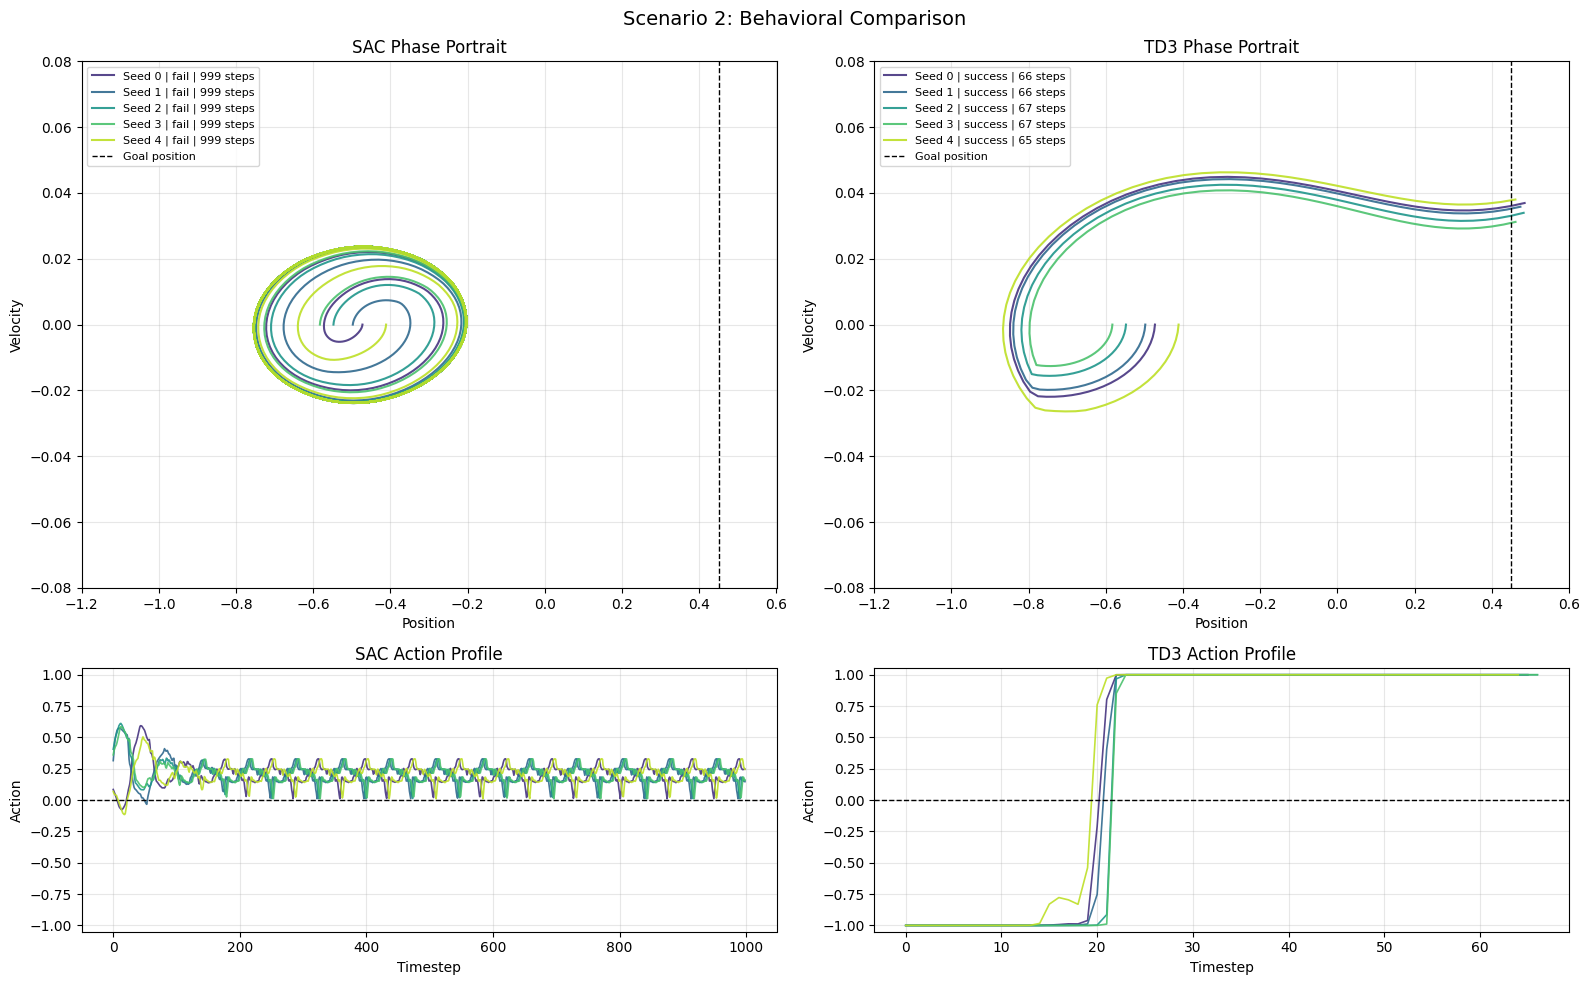

Behavior summary over 5 deterministic rollouts:


,Successes / 5,Avg Steps,Avg Fuel Proxy,Avg |Action|,Avg Max Position
Algorithm,,,,,
SAC,0,999.0,50.14,0.21,-0.20
TD3,5,66.2,65.02,0.99,0.47


In [4]:
def run_continuous_episode(model, env_name="MountainCarContinuous-v0", max_steps=999, seed=None):
    env = gym.make(env_name)
    state, _ = env.reset(seed=seed)

    positions = [float(state[0])]
    velocities = [float(state[1])]
    actions = []
    rewards = []

    for _ in range(max_steps):
        action, _ = model.predict(state, deterministic=True)
        action_array = np.asarray(action, dtype=np.float32).reshape(-1)

        next_state, reward, terminated, truncated, _ = env.step(action_array)

        actions.append(float(action_array[0]))
        rewards.append(float(reward))
        positions.append(float(next_state[0]))
        velocities.append(float(next_state[1]))

        state = next_state

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "rewards": rewards,
        "steps": len(actions),
        "fuel_used": float(np.sum(np.square(actions))),
        "avg_abs_action": float(np.mean(np.abs(actions))) if actions else 0.0,
        "max_position": float(np.max(positions)) if positions else float("nan"),
        "success": bool(positions[-1] >= 0.45) if positions else False,
    }


MODELS_DIR_2 = SCENARIO2_DIR / "models"
sac_model = SAC.load(MODELS_DIR_2 / "scenario2_sac")
td3_model = TD3.load(MODELS_DIR_2 / "scenario2_td3")

seeds = list(range(5))
episodes_by_algorithm = {
    "SAC": [run_continuous_episode(sac_model, seed=seed) for seed in seeds],
    "TD3": [run_continuous_episode(td3_model, seed=seed) for seed in seeds],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={"height_ratios": [2, 1]})
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(seeds)))

goal_position = 0.45

for column, algorithm in enumerate(["SAC", "TD3"]):
    phase_ax = axes[0, column]
    action_ax = axes[1, column]

    for color, seed, episode in zip(colors, seeds, episodes_by_algorithm[algorithm]):
        outcome = "success" if episode["success"] else "fail"
        phase_ax.plot(
            episode["positions"],
            episode["velocities"],
            color=color,
            linewidth=1.5,
            alpha=0.9,
            label=f"Seed {seed} | {outcome} | {episode['steps']} steps",
        )
        action_ax.plot(
            episode["actions"],
            color=color,
            linewidth=1.2,
            alpha=0.9,
            label=f"Seed {seed}",
        )

    phase_ax.axvline(goal_position, color="black", linestyle="--", linewidth=1, label="Goal position")
    phase_ax.set_xlim(-1.2, 0.6)
    phase_ax.set_ylim(-0.08, 0.08)
    phase_ax.set_xlabel("Position")
    phase_ax.set_ylabel("Velocity")
    phase_ax.set_title(f"{algorithm} Phase Portrait")
    phase_ax.grid(True, alpha=0.3)
    phase_ax.legend(fontsize=8, loc="best")

    action_ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    action_ax.set_ylim(-1.05, 1.05)
    action_ax.set_xlabel("Timestep")
    action_ax.set_ylabel("Action")
    action_ax.set_title(f"{algorithm} Action Profile")
    action_ax.grid(True, alpha=0.3)

plt.suptitle("Scenario 2: Behavioral Comparison", fontsize=14)
plt.tight_layout()
plt.show()

behavior_rows = []
for algorithm, episodes in episodes_by_algorithm.items():
    behavior_rows.append(
        {
            "Algorithm": algorithm,
            "Successes / 5": sum(episode["success"] for episode in episodes),
            "Avg Steps": np.mean([episode["steps"] for episode in episodes]),
            "Avg Fuel Proxy": np.mean([episode["fuel_used"] for episode in episodes]),
            "Avg |Action|": np.mean([episode["avg_abs_action"] for episode in episodes]),
            "Avg Max Position": np.mean([episode["max_position"] for episode in episodes]),
        }
    )

print("Behavior summary over 5 deterministic rollouts:")
pd.DataFrame(behavior_rows).set_index("Algorithm").round(2)

### Scenario 2 Interpretation and Conclusion

In Scenario 2, **TD3 was clearly the stronger algorithm**. It solved the continuous MountainCar task with **100% reliability**, reached the goal in a tightly concentrated **65-67 step** band, and converged faster during training. Both the metric table and the training curves point to the same result: TD3 found a stable policy and kept it.

The behavior plots explain *why* the final metrics look so different. **TD3's phase portraits** show clean oscillatory loops that progressively build momentum and then transition into a successful climb. Its **action profiles** are decisive and structured, which is exactly what this environment requires: apply force when it matters, then cash that momentum into a short successful episode.

**SAC**, by contrast, improved under the shaped reward without learning the full task. Its reward curve rises, but the step curve remains flat at the timeout limit, and its trajectories stay trapped in ineffective oscillations. This is a good example of why training reward alone is not enough for interpretation.

A final nuance is that **lower raw fuel usage does not automatically mean better fuel efficiency**. SAC uses less force overall, but only because it never reaches the goal. TD3 spends slightly more fuel, yet does so in service of consistently solving the problem in a short horizon. For this scenario, that is the more meaningful notion of efficiency.

Overall, Scenario 2 shows that for **continuous MountainCar with a fuel-sensitive objective**, **TD3's deterministic and stable control** was much better suited to the problem than SAC's entropy-regularized exploration.